## Step 1. Roboflow API로 데이터셋 다운로드

In [1]:
# 1. 설치
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 112.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [2]:
# 2. 다운로드
from roboflow import Roboflow

rf = Roboflow(api_key="YOUR_API_KEY")  # Roboflow 계정 API 키 입력
project = rf.workspace("s-workspace-6sd3n").project("noongil-barrierfree-ai")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to NoonGil-BarrierFree-AI-1 in yolov8:: 100%|██████████| 777/777 [00:00<00:00, 7283.62it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
print(dataset.location)

/content/NoonGil-BarrierFree-AI-1


## Step 2. data.yaml 경로 확인

In [18]:
import os, shutil, random

base = "/content/NoonGil-BarrierFree-AI-1"
train_img = f"{base}/train/images"
train_lbl = f"{base}/train/labels"
val_img   = f"{base}/valid/images"
val_lbl   = f"{base}/valid/labels"
test_img  = f"{base}/test/images"
test_lbl  = f"{base}/test/labels"

os.makedirs(val_img, exist_ok=True)
os.makedirs(val_lbl, exist_ok=True)
os.makedirs(test_img, exist_ok=True)
os.makedirs(test_lbl, exist_ok=True)

# 전체 이미지 목록
imgs = [f for f in os.listdir(train_img) if f.endswith(('.jpg','.png'))]
random.seed(42)
random.shuffle(imgs)

# 7:2:1 분할
n = len(imgs)
val_imgs  = imgs[int(n*0.7):int(n*0.9)]
test_imgs = imgs[int(n*0.9):]

def move_split(file_list, src_img, src_lbl, dst_img, dst_lbl):
    for fname in file_list:
        shutil.move(f"{src_img}/{fname}", f"{dst_img}/{fname}")
        lbl = fname.rsplit('.', 1)[0] + '.txt'
        if os.path.exists(f"{src_lbl}/{lbl}"):
            shutil.move(f"{src_lbl}/{lbl}", f"{dst_lbl}/{lbl}")

move_split(val_imgs,  train_img, train_lbl, val_img, val_lbl)
move_split(test_imgs, train_img, train_lbl, test_img, test_lbl)

print(f"train: {len(os.listdir(train_img))}, val: {len(os.listdir(val_img))}, test: {len(os.listdir(test_img))}")

train: 270, val: 78, test: 39


In [19]:
import yaml

yaml_path = f"{base}/data.yaml"
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = train_img
data['val']   = val_img
data['test']  = test_img

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, allow_unicode=True)

print("data.yaml 수정 완료")
!cat {yaml_path}

data.yaml 수정 완료
names:
- bench
- bicycle
- bollard
- clothing_bin
- cone
- electric_scooter
- fire_hydrant
- motorcycle
- pavement_damage
- ramp
- step
- street_light
- trash
- tree
nc: 14
roboflow:
  license: CC BY 4.0
  project: noongil-barrierfree-ai
  url: https://universe.roboflow.com/s-workspace-6sd3n/noongil-barrierfree-ai/dataset/1
  version: 1
  workspace: s-workspace-6sd3n
test: /content/NoonGil-BarrierFree-AI-1/test/images
train: /content/NoonGil-BarrierFree-AI-1/train/images
val: /content/NoonGil-BarrierFree-AI-1/valid/images


In [15]:
# valid 폴더가 없으면 train으로 임시 설정
if not os.path.exists(f"{base}/valid/images"):
    print("valid 없음 → train으로 대체")
    data['val'] = f"{base}/train/images"

    with open(yaml_path, 'w') as f:
        yaml.dump(data, f, allow_unicode=True)

valid 없음 → train으로 대체


## Step 3. YOLOv8 학습 실행

In [20]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=512,
    batch=16,
    name="noongil_v2",   # 새 실험명
    project="runs/detect",
    device=0,
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/NoonGil-BarrierFree-AI-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=noongil_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

## Step 4. 학습 후 평가

In [21]:
# Validation (mAP 확인)
metrics = model.val()
print(f"mAP@50:    {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")

# test 추론
results = model.predict(
    source=test_img,
    conf=0.25,
    save=True
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1769.2±638.3 MB/s, size: 48.7 KB)
val: Scanning /content/NoonGil-BarrierFree-AI-1/valid/labels.cache... 78 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 29.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.3it/s 2.2s
                   all         78        136      0.896      0.944      0.975      0.664
                 bench          4         10      0.965          1      0.995      0.637
               bicycle         23         28      0.928          1      0.994      0.726
               bollard          9         12       0.96          1      0.995      0.712
          clothing_bin          2          2      0.811          1      0.995      0.995
                  cone          6    

In [23]:
import glob

# 저장된 모든 best.pt 경로 찾기
weights = glob.glob("/content/runs/detect/**/weights/best.pt", recursive=True)
for w in weights:
    print(w)

/content/runs/detect/runs/detect/noongil_v1-4/weights/best.pt
/content/runs/detect/runs/detect/noongil_v2/weights/best.pt


In [24]:
import shutil, os

os.makedirs("/content/drive/MyDrive/NoonGil/weights", exist_ok=True)

shutil.copy(
    "/content/runs/detect/runs/detect/noongil_v2/weights/best.pt",
    "/content/drive/MyDrive/NoonGil/weights/noongil_v2_best.pt"
)
print("백업 완료!")

백업 완료!


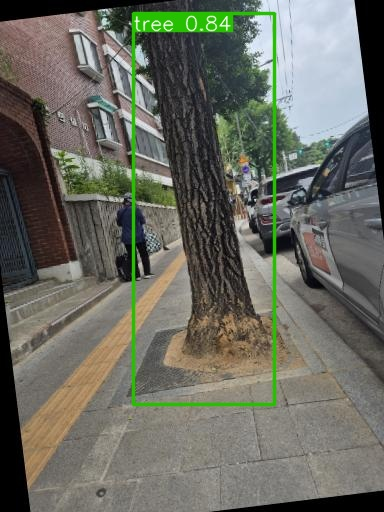

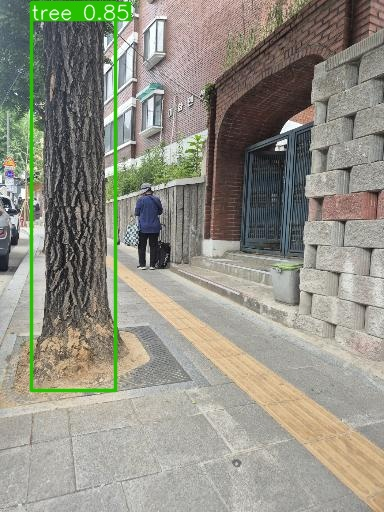

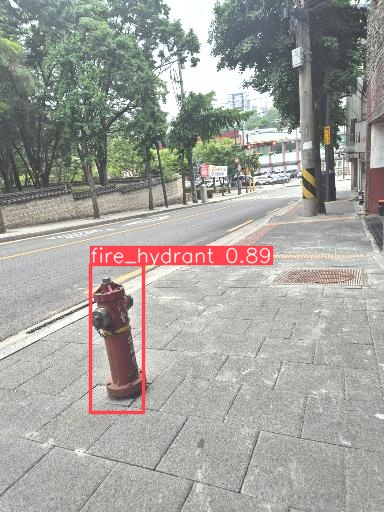

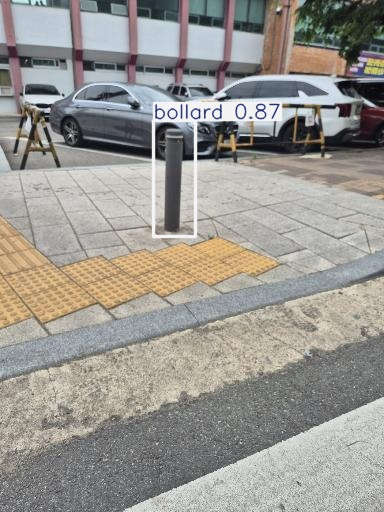

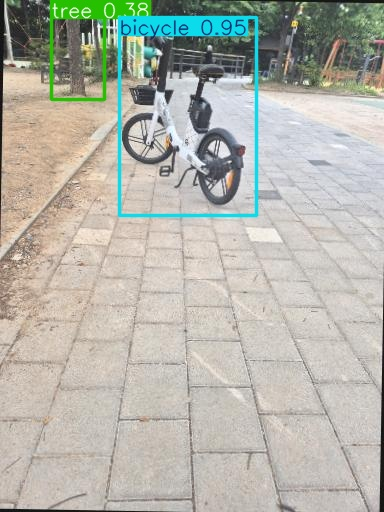

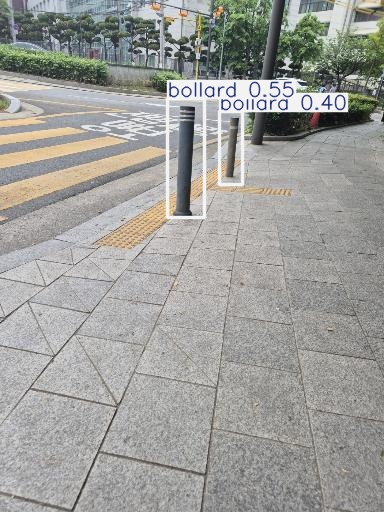

In [25]:
import glob
from IPython.display import Image, display

pred_imgs = glob.glob("/content/runs/detect/predict/*.jpg")[:6]
for img in pred_imgs:
    display(Image(img, width=512))

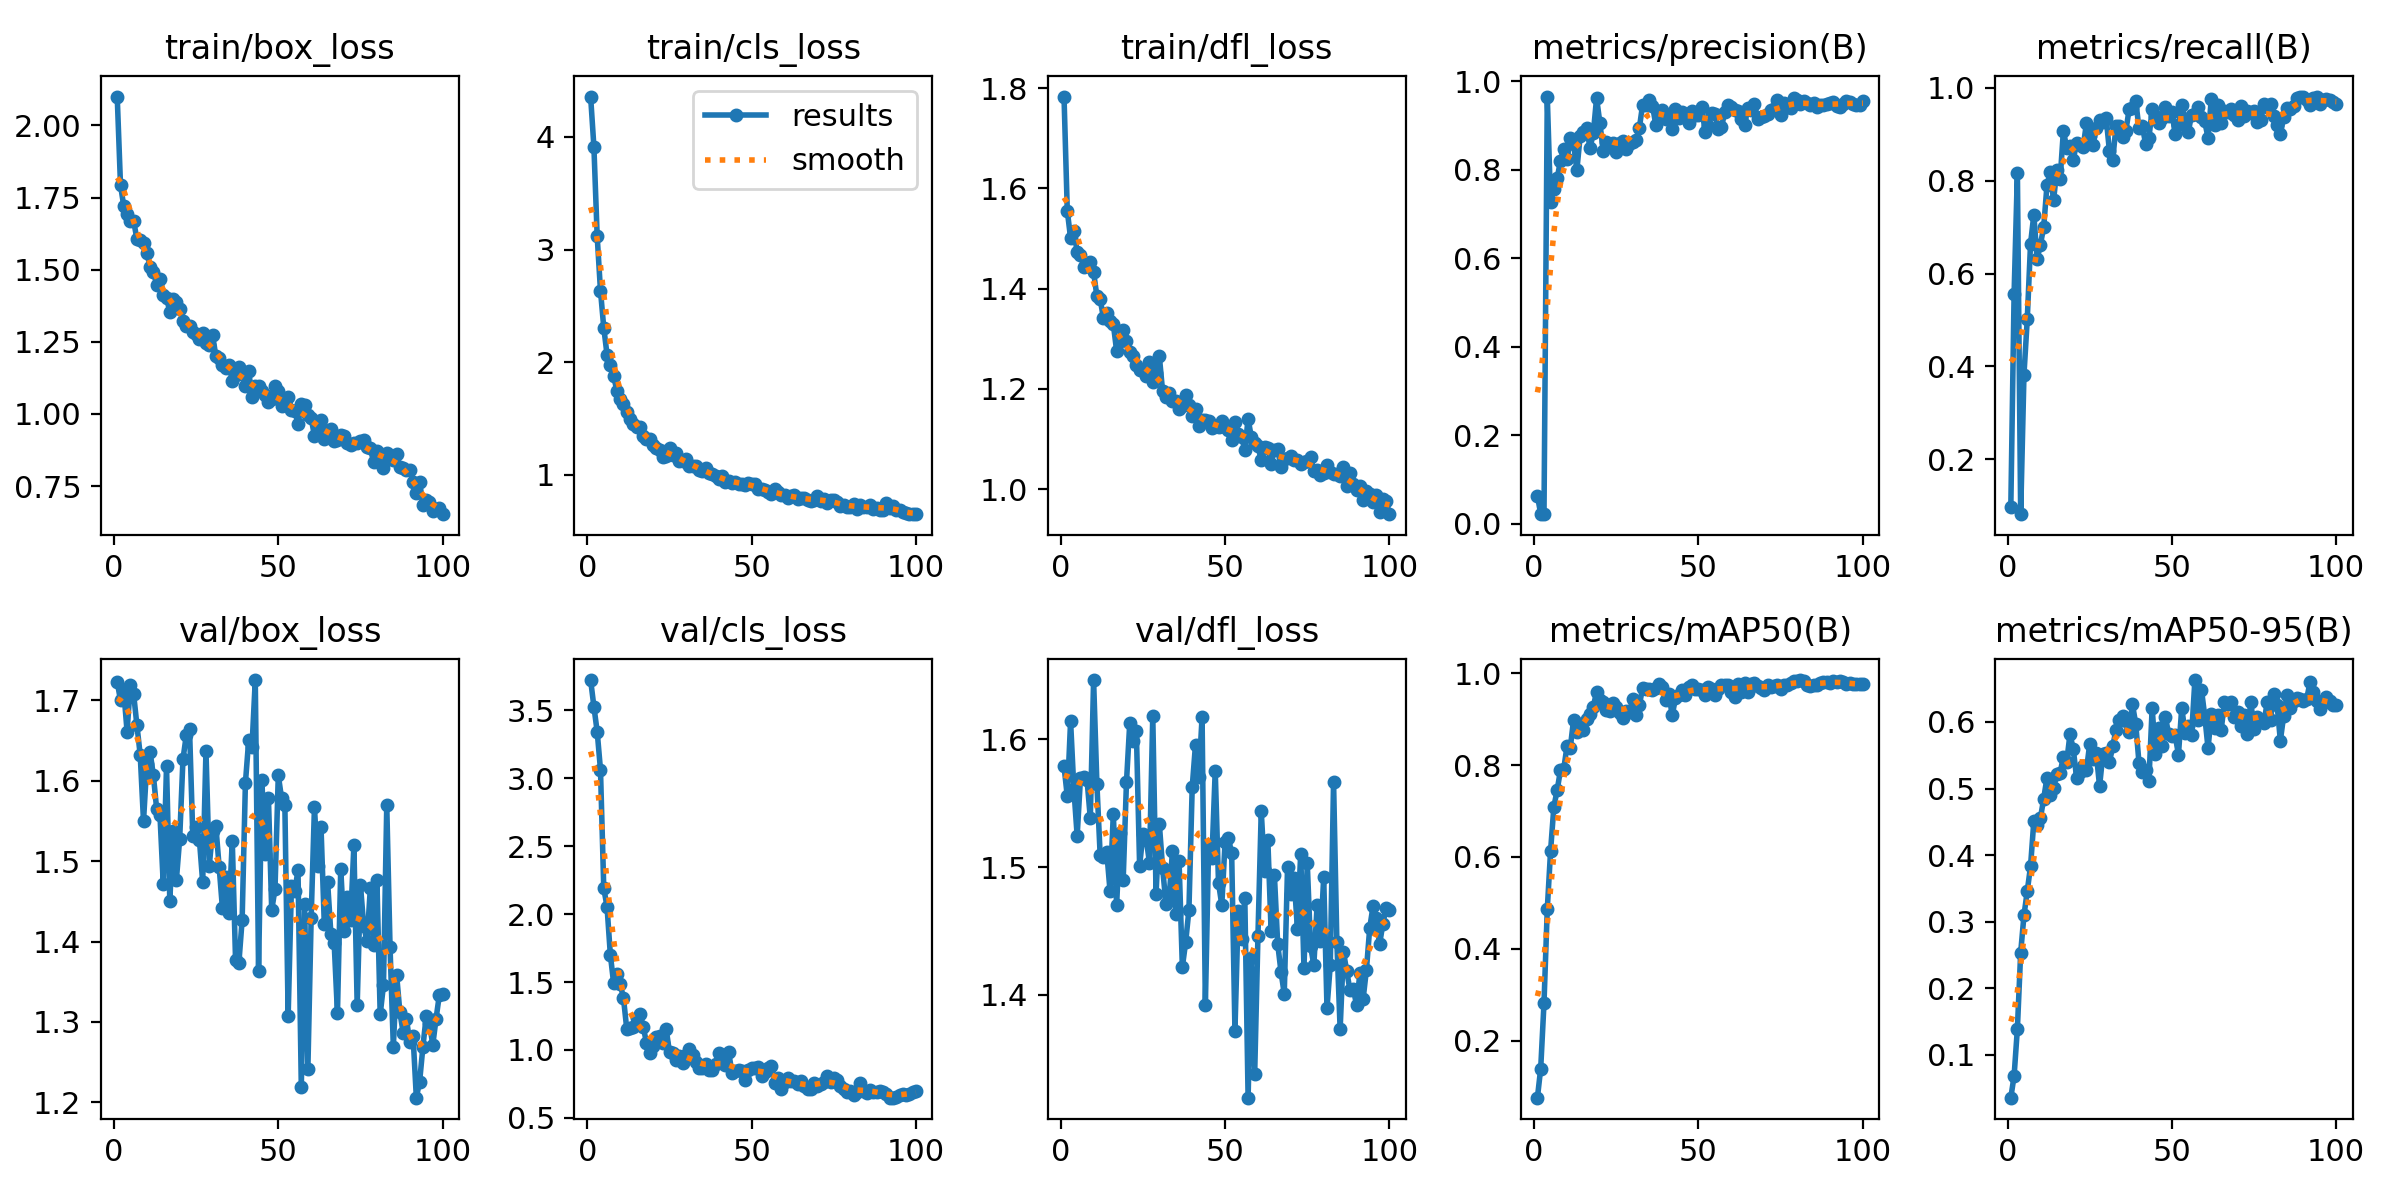

In [27]:
from IPython.display import Image
Image("/content/runs/detect/runs/detect/noongil_v2/results.png", width=900)